# Optimizations

We apply three optimization techniques, each targeting a profiled bottleneck:

1. **KV-Cache** — eliminate redundant key/value recomputation
2. **INT8 Quantization** — reduce weight memory and speed up matmul
3. **Async Batching** — process multiple prompts in a single forward pass

Each optimization is benchmarked independently, then we show cumulative results.

In [1]:
import sys
sys.path.insert(0, "..")

from src.model import load_model_and_tokenizer
from src.inference import generate, generate_manual
from src.kv_cache import generate_with_kv_cache
from src.quantization import quantize_model, generate_quantized, get_model_size_mb
from src.async_batching import generate_batched, run_batched_benchmark
from src.benchmark import run_benchmark, compare_benchmarks, plot_speedups
from src.profiling import (
    profile_generate, line_profile_function,
    memory_profile_generate, get_model_memory_footprint,
)
from src.config import BENCHMARK_PROMPTS, QUALITY_CHECK_PROMPTS

In [2]:
model, tokenizer = load_model_and_tokenizer()
print(f"Model: {model.config._name_or_path}")
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Model size: {get_model_size_mb(model):.1f} MB")

`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Model: gpt2
Parameters: 124,439,808
Model size: 474.7 MB


---
## 1. Profiling the Baseline

Before optimizing, we identify exactly where time and memory are spent.

### 1a. cProfile (function-level)

In [3]:
cprofile_result = profile_generate(
    model, tokenizer, "The meaning of life is",
    generate_fn=generate_manual, max_new_tokens=50,
)
print(cprofile_result["profile_stats"])

         121954 function calls (105498 primitive calls) in 1.409 seconds

   Ordered by: cumulative time
   List reduced from 191 to 30 due to restriction <30>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        1    0.000    0.000    1.409    1.409 _contextlib.py:120(decorate_context)
        1    0.004    0.004    1.409    1.409 inference.py:60(generate_manual)
  7550/50    0.005    0.000    1.354    0.027 module.py:1775(_wrapped_call_impl)
  7550/50    0.010    0.000    1.354    0.027 module.py:1783(_call_impl)
       50    0.000    0.000    1.353    0.027 generic.py:870(wrapper)
       50    0.001    0.000    1.353    0.027 modeling_gpt2.py:656(forward)
       50    0.000    0.000    1.005    0.020 generic.py:890(wrapper)
       50    0.001    0.000    1.005    0.020 output_capturing.py:217(wrapper)
       50    0.004    0.000    1.003    0.020 modeling_gpt2.py:519(forward)
      600    0.001    0.000    0.987    0.002 modeling_layers.py:59(__call__)
  

### 1b. line_profiler (line-level hotspots)

In [4]:
lp_result = line_profile_function(
    generate_manual, model, tokenizer, "The meaning of life is", max_new_tokens=50,
)
print(lp_result["report"])

/Users/shriranjanpatil/Data/NYU/Spring_26/Adv_Python_DS/Final_Project/.venv/lib/python3.11/site-packages/line_profiler/line_profiler.py:529: UserWarning: Adding a function with a `.__wrapped__` attribute. You may want to profile the wrapped function by adding `generate_manual.__wrapped__` instead.
  self.add_function(impl)


Timer unit: 1e-09 s

Total time: 1.38025 s
File: /Users/shriranjanpatil/Data/NYU/Spring_26/Adv_Python_DS/Final_Project/notebooks/../src/inference.py
Function: generate_manual at line 60

Line #      Hits         Time  Per Hit   % Time  Line Contents
    60                                           @torch.no_grad()
    61                                           def generate_manual(
    62                                               model: PreTrainedModel,
    63                                               tokenizer: PreTrainedTokenizer,
    64                                               prompt: str,
    65                                               max_new_tokens: int = MAX_NEW_TOKENS,
    66                                               temperature: float = TEMPERATURE,
    67                                               top_k: int = TOP_K,
    68                                           ) -> dict:
    69                                               """
    70            

### 1c. Memory profiling

In [5]:
mem_result = memory_profile_generate(
    model, tokenizer, "The meaning of life is",
    generate_fn=generate_manual, max_new_tokens=50,
)
print(f"Peak memory during generation: {mem_result['peak_memory_mb']:.2f} MB")
print(f"\nTop allocations:")
for alloc in mem_result["top_allocations"][:10]:
    print(f"  {alloc['size_kb']:.1f} KB  ({alloc['count']} allocs)  {alloc['file']}")

Peak memory during generation: 0.12 MB

Top allocations:
  49.6 KB  (600 allocs)  /Users/shriranjanpatil/.local/share/uv/python/cpython-3.11.13-macos-aarch64-none/lib/python3.11/dataclasses.py:1250
  15.8 KB  (242 allocs)  /Users/shriranjanpatil/Data/NYU/Spring_26/Adv_Python_DS/Final_Project/.venv/lib/python3.11/site-packages/transformers/pytorch_utils.py:122
  12.9 KB  (196 allocs)  /Users/shriranjanpatil/Data/NYU/Spring_26/Adv_Python_DS/Final_Project/.venv/lib/python3.11/site-packages/transformers/cache_utils.py:99
  8.8 KB  (135 allocs)  /Users/shriranjanpatil/Data/NYU/Spring_26/Adv_Python_DS/Final_Project/.venv/lib/python3.11/site-packages/transformers/cache_utils.py:98
  5.1 KB  (76 allocs)  /Users/shriranjanpatil/Data/NYU/Spring_26/Adv_Python_DS/Final_Project/.venv/lib/python3.11/site-packages/transformers/utils/output_capturing.py:225
  3.9 KB  (68 allocs)  /Users/shriranjanpatil/Data/NYU/Spring_26/Adv_Python_DS/Final_Project/.venv/lib/python3.11/site-packages/transformers/cache

---
## 2. Baseline Benchmark

In [6]:
print("Benchmarking baseline (manual loop, no optimizations)...")
baseline_results = run_benchmark(
    model, tokenizer, generate_manual,
    label="baseline (no cache)",
    save_path="../benchmark_results/phase2_baseline.json",
)
print(f"Baseline: {baseline_results['overall_tok_per_sec_mean']:.2f} tok/s")

Benchmarking baseline (manual loop, no optimizations)...
  [1/10] Benchmarking: The meaning of life is...
  [2/10] Benchmarking: In a distant galaxy, a lone astronaut discovered...
  [3/10] Benchmarking: The Python programming language was created by...
  [4/10] Benchmarking: Once upon a time in a land far away,...
  [5/10] Benchmarking: The capital of France is...
  [6/10] Benchmarking: Explain how a neural network works:...
  [7/10] Benchmarking: The quick brown fox jumps over the...
  [8/10] Benchmarking: In the year 2050, technology has advanced to the p...
  [9/10] Benchmarking: What is 2 + 2? The answer is...
  [10/10] Benchmarking: The three laws of thermodynamics state that...
  Results saved to ../benchmark_results/phase2_baseline.json
Baseline: 19.25 tok/s


---
## 3. Optimization 1: KV-Cache

**Bottleneck:** Without caching, the model recomputes K/V projections for ALL previous tokens at every step — O(seq_len) redundant work per token.

**Fix:** Cache K/V tensors and only process the new token at each step.

In [7]:
# Quick sanity check
result = generate_with_kv_cache(model, tokenizer, "The meaning of life is", max_new_tokens=50)
print(f"KV-Cache tok/s: {result['tok_per_sec']:.2f}")
print(f"Text: {result['text'][:200]}")

KV-Cache tok/s: 80.37
Text: The meaning of life is at stake in the final judgment of the Court of Appeals. The right to live is at stake not only when the court upholds a statute in a petition that it believes has been struck do


In [8]:
print("Benchmarking KV-Cache...")
kv_results = run_benchmark(
    model, tokenizer, generate_with_kv_cache,
    label="+ KV-Cache",
    save_path="../benchmark_results/phase2_kv_cache.json",
)
print(f"KV-Cache: {kv_results['overall_tok_per_sec_mean']:.2f} tok/s")

Benchmarking KV-Cache...
  [1/10] Benchmarking: The meaning of life is...
  [2/10] Benchmarking: In a distant galaxy, a lone astronaut discovered...
  [3/10] Benchmarking: The Python programming language was created by...
  [4/10] Benchmarking: Once upon a time in a land far away,...
  [5/10] Benchmarking: The capital of France is...
  [6/10] Benchmarking: Explain how a neural network works:...
  [7/10] Benchmarking: The quick brown fox jumps over the...
  [8/10] Benchmarking: In the year 2050, technology has advanced to the p...
  [9/10] Benchmarking: What is 2 + 2? The answer is...
  [10/10] Benchmarking: The three laws of thermodynamics state that...
  Results saved to ../benchmark_results/phase2_kv_cache.json
KV-Cache: 80.61 tok/s


---
## 4. Optimization 2: INT8 Quantization

**Bottleneck:** FP32 weights (475 MB) consume memory bandwidth during matmul.

**Fix:** Quantize weights to INT8 (1 byte each), reducing memory ~4×. Dequantize on the fly during forward pass.

In [9]:
print("Quantizing model to INT8...")
quantized_model = quantize_model(model)
print(f"Original model size: {get_model_size_mb(model):.1f} MB")
print(f"Quantized model size: {get_model_size_mb(quantized_model):.1f} MB")
print(f"Reduction: {(1 - get_model_size_mb(quantized_model) / get_model_size_mb(model)) * 100:.1f}%")

Quantizing model to INT8...
Original model size: 474.7 MB
Quantized model size: 268.5 MB
Reduction: 43.4%


In [10]:
# Sanity check
result = generate_quantized(quantized_model, tokenizer, "The meaning of life is", max_new_tokens=50)
print(f"Quantized tok/s: {result['tok_per_sec']:.2f}")
print(f"Text: {result['text'][:200]}")

Quantized tok/s: 27.36
Text: The meaning of life is to get along well. This means that you don't have to worry about how others will act. You can get along very well by sitting up and enjoying the night out and enjoying our time 


In [11]:
print("Benchmarking INT8 Quantization + KV-Cache...")
quant_results = run_benchmark(
    quantized_model, tokenizer, generate_quantized,
    label="+ Quantization (INT8)",
    save_path="../benchmark_results/phase2_quantized.json",
)
print(f"Quantized: {quant_results['overall_tok_per_sec_mean']:.2f} tok/s")

Benchmarking INT8 Quantization + KV-Cache...
  [1/10] Benchmarking: The meaning of life is...
  [2/10] Benchmarking: In a distant galaxy, a lone astronaut discovered...
  [3/10] Benchmarking: The Python programming language was created by...
  [4/10] Benchmarking: Once upon a time in a land far away,...
  [5/10] Benchmarking: The capital of France is...
  [6/10] Benchmarking: Explain how a neural network works:...
  [7/10] Benchmarking: The quick brown fox jumps over the...
  [8/10] Benchmarking: In the year 2050, technology has advanced to the p...
  [9/10] Benchmarking: What is 2 + 2? The answer is...
  [10/10] Benchmarking: The three laws of thermodynamics state that...
  Results saved to ../benchmark_results/phase2_quantized.json
Quantized: 27.54 tok/s


---
## 5. Optimization 3: Async Batching

**Bottleneck:** Processing one prompt at a time — fixed per-request overhead is paid repeatedly.

**Fix:** Batch multiple prompts into a single forward pass so matrix operations are larger and more hardware-efficient.

In [12]:
# Sanity check — batch of 4 prompts
batch_results = generate_batched(
    model, tokenizer,
    ["The meaning of life is", "In a distant galaxy,", "Python was created by", "The capital of France is"],
    max_new_tokens=50,
)
for r in batch_results:
    print(f"  [{r['tok_per_sec']:.1f} tok/s] {r['text'][:100]}")
    print()

  [41.9 tok/s] The meaning of life is that there is something here for everyone. In that they become human and they

  [41.9 tok/s] In a distant galaxy, the main engine of civilization was designed to produce starships and asteroids

  [41.9 tok/s] Python was created by its created by its created by its created by its its its its its its its its i

  [41.9 tok/s] The capital of France is where many of the biggest problems lie.

"I hope to be able to get a visa t



In [13]:
print("Benchmarking Async Batching (batch_size=4)...")
batch_bench = run_batched_benchmark(
    model, tokenizer, BENCHMARK_PROMPTS,
    batch_size=4, max_new_tokens=200,
)
print(f"Batched (bs=4): {batch_bench['overall_tok_per_sec_mean']:.2f} tok/s")

Benchmarking Async Batching (batch_size=4)...
Batched (bs=4): 176.37 tok/s


---
## 6. Cumulative Comparison

In [14]:
all_results = [baseline_results, kv_results, quant_results, batch_bench]
compare_benchmarks(all_results)


Label                       tok/s (mean)    tok/s (std)    Speedup
-----------------------------------------------------------------
baseline (no cache)                19.25           4.18      1.00x
+ KV-Cache                         80.61           5.82      4.19x
+ Quantization (INT8)              27.54           0.34      1.43x
async_batch_4                     176.37           2.58      9.16x


  Plot saved to ../benchmark_results/phase2_comparison.png


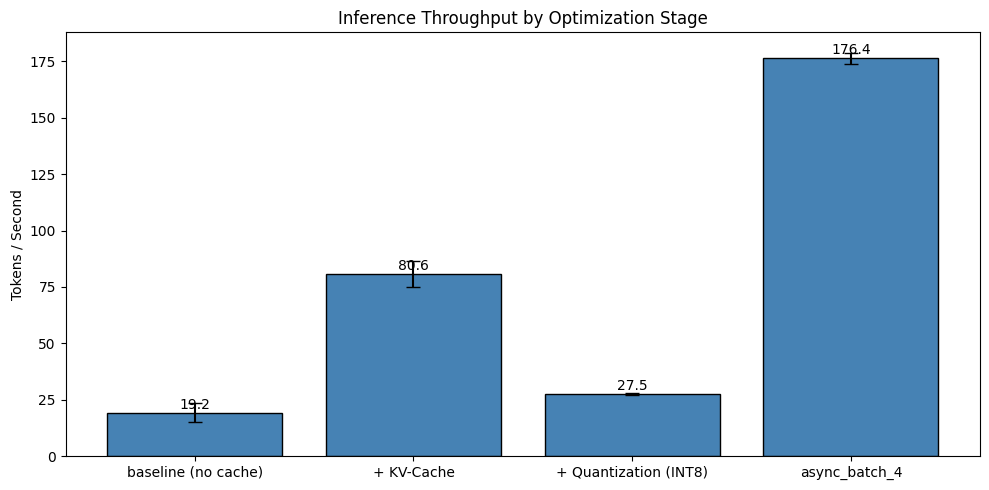

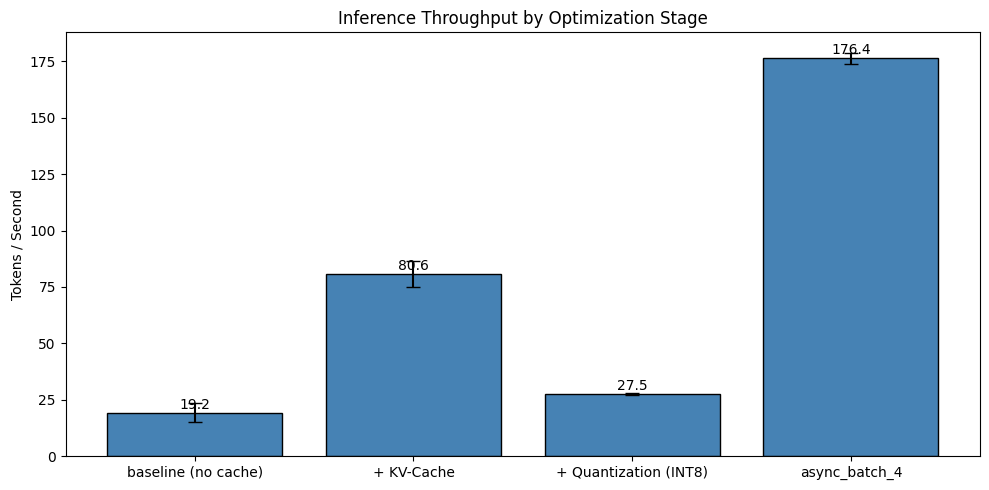

In [15]:
fig = plot_speedups(all_results, save_path="../benchmark_results/phase2_comparison.png")
fig

---
## 7. Quality Sanity Check

Verify outputs remain coherent after each optimization.

In [16]:
print("=" * 80)
for prompt in QUALITY_CHECK_PROMPTS:
    print(f"\nPrompt: {prompt}")
    
    baseline_out = generate_manual(model, tokenizer, prompt, max_new_tokens=30)
    print(f"  Baseline:    {baseline_out['text'][:120]}")
    
    kv_out = generate_with_kv_cache(model, tokenizer, prompt, max_new_tokens=30)
    print(f"  KV-Cache:    {kv_out['text'][:120]}")
    
    quant_out = generate_quantized(quantized_model, tokenizer, prompt, max_new_tokens=30)
    print(f"  Quantized:   {quant_out['text'][:120]}")
    
print("\n" + "=" * 80)


Prompt: What is 2 + 2? The answer is
  Baseline:    What is 2 + 2? The answer is 1 – 2, and so on up and to infinity (there is no 2 with 3). So the above is a simple set of
  KV-Cache:    What is 2 + 2? The answer is that the number 2 in this case is of significance to him. It is important therefore, if you
  Quantized:   What is 2 + 2? The answer is 1.

For 2 + 2 we assume a square root of 4 times (add x to it) and a positive sum of three 

Prompt: The capital of France is
  Baseline:    The capital of France is Paris, French with English roots.


In 1778 the first French census showed Paris had a populati
  KV-Cache:    The capital of France is the capital of France. And if you want to live in France, you ought to know how much the French
  Quantized:   The capital of France is becoming increasingly anti-Semitic. The police announced last week that many of the young peopl

Prompt: Water freezes at
  Baseline:    Water freezes at least 500 feet, the temperature at which a body freeze

---
## 8. Memory Comparison

In [17]:
print(f"Original model:  {get_model_size_mb(model):.1f} MB")
print(f"Quantized model: {get_model_size_mb(quantized_model):.1f} MB")
print(f"\nOriginal footprint:")
for k, v in get_model_memory_footprint(model).items():
    print(f"  {k}: {v}")
print(f"\nQuantized footprint:")
for k, v in get_model_memory_footprint(quantized_model).items():
    print(f"  {k}: {v}")

Original model:  474.7 MB
Quantized model: 268.5 MB

Original footprint:
  num_parameters: 124439808
  param_memory_mb: 474.7001953125
  buffer_memory_mb: 0.0
  total_memory_mb: 474.7001953125
  dtype: torch.float32

Quantized footprint:
  num_parameters: 39422208
  param_memory_mb: 150.3837890625
  buffer_memory_mb: 118.12591934204102
  total_memory_mb: 268.509708404541
  dtype: torch.float32


---
## Summary

| Optimization | Technique | Bottleneck Addressed | Course Tool |
|---|---|---|---|
| KV-Cache | Cache K/V tensors across steps | Redundant attention recomputation | NumPy, PyTorch |
| Quantization | INT8 weights + dequantize on fly | FP32 memory bandwidth | Numba, NumPy |
| Async Batching | Batch prompts in single forward pass | Per-request overhead, underutilized HW | asyncio |